In [1]:
import pandas as pd
from pathlib import Path
import json
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
datasets = {
    "TSF": ["Azure_metrics", "WSD_3k_metrics"],
    "TSAD": ["AIOPS_metrics", "WSD_metrics"],
    "SSD": ["fbeta.2_jmh", "fbeta.2_VMs"]
}

In [4]:
with open("config/config.json") as c_file:
    config = json.loads(c_file.read())

In [5]:
dfs = []
conf_level = 0.95

def format_scientific_if_large(x):
    if abs(x) > 100:
        return f"{x:.1e}"
    else:
        return str(x)


for task in config["tasks"]:
    for dataset in task['datasets']:
        dataset_id = dataset["dataset_id"]
        # print(dataset_id)
        feature_df = pd.read_csv(dataset["feature_path"], index_col=[0])
        basic_subset = [
            'y__variation_coefficient', 
            # 'y__variance', 
            # 'y__autocorrelation__lag_1',
            'y__partial_autocorrelation__lag_1',
            'y__binned_entropy__max_bins_10',
            'y__ratio_beyond_r_sigma__r_1.5',
            'y__standard_deviation'
            ]
        
        item = {
            "Task": task['task_type'],
            "Dataset": dataset['dataset_id']
        }

        for foi in basic_subset:
            foi_mean = feature_df[foi].mean()
            foi_sem = feature_df[foi].sem()
            ci_range = foi_sem * stats.t.ppf((1 + conf_level) / 2, len(feature_df) - 1)
            item.update({f"Mean {foi}": f"{format_scientific_if_large(foi_mean.round(2))} $\pm$ {format_scientific_if_large(ci_range.round(3))}"})

        median_variance = feature_df['y__variance'].median()
        variance_skewness = feature_df['y__variance'].skew()

        item.update({
            # 'median_variance': median_variance,
            'variance_skewness': variance_skewness
        })

        dfs.append(item)

dfs = pd.DataFrame(dfs)
dfs.rename(columns = {
    "Mean y__variation_coefficient": "Mean CV",
    "Mean y__binned_entropy__max_bins_10": "Mean Entropy",
    "Mean y__ratio_beyond_r_sigma__r_1.5": "Mean OutR1.5",
    "Mean y__standard_deviation": "Mean $\sigma$",
    'Mean y__partial_autocorrelation__lag_1': 'Mean PACF(1)',
    "variance_skewness": "Variance Skewness"
}, inplace=True)

dfs.replace("_", " ", regex=True, inplace=True)
dfs.replace("steady-state", "SSPD", regex=True, inplace=True)
dfs.replace("timeseries-forecasting", "TSF", regex=True, inplace=True)
dfs.replace("anomaly-detection", "TSAD", regex=True, inplace=True)

dfs.to_latex(f"results/tex/dataset_analysis.tex", index=False, escape=False, float_format="%.2f")
dfs
        

,Task,Dataset,Mean CV,Mean PACF(1),Mean Entropy,Mean OutR1.5,Mean $\sigma$,Variance Skewness
0,SSPD,jmh,1.95 $\pm$ 0.185,0.24 $\pm$ 0.007,0.23 $\pm$ 0.01,0.04 $\pm$ 0.001,0.02 $\pm$ 0.003,23.081250
1,SSPD,VMs,0.03 $\pm$ 0.003,0.38 $\pm$ 0.013,0.63 $\pm$ 0.023,0.06 $\pm$ 0.002,0.05 $\pm$ 0.007,6.964801
2,TSF,WSD 3k,0.29 $\pm$ 0.016,0.93 $\pm$ 0.012,1.88 $\pm$ 0.042,0.13 $\pm$ 0.004,6.7e+02 $\pm$ 1.1e+02,1.396738
3,TSF,AzFuncInvoke,0.65 $\pm$ 0.056,0.8 $\pm$ 0.029,1.57 $\pm$ 0.057,0.09 $\pm$ 0.004,4.9e+03 $\pm$ 1.2e+03,6.542652
4,TSAD,AIOps,1.46 $\pm$ 5.358,0.9 $\pm$ 0.078,1.01 $\pm$ 0.24,0.08 $\pm$ 0.018,9.73 $\pm$ 4.933,1.937262
5,TSAD,WSD,0.34 $\pm$ 0.024,0.95 $\pm$ 0.009,1.58 $\pm$ 0.062,0.13 $\pm$ 0.005,7.2e+02 $\pm$ 1.2e+02,1.277186


In [6]:
dfs = []
for task in config["tasks"]:
    for dataset in task['datasets']:
        dataset_id = dataset["dataset_id"]
        selected_df = pd.read_csv(dataset["selected_feature_path"], index_col=[0])
        feature_names = {col.split("__")[1] for col in selected_df.columns if "__" in col}
        kinds = {col.split("__")[0] for col in selected_df.columns if "__" in col}
        dfs.append({
            "Dataset": dataset_id,
            "Extracted": len(pd.read_csv(dataset["feature_path"], index_col=[0]).columns),
            "ρ-Filtered": "?",
            "RFE Chosen (Final)": len(selected_df.columns),
            "Feature Types": len(feature_names),
        })

df = pd.DataFrame(dfs)
df.to_latex("results/tex/features.tex", column_format="l|rr|rr", index=False, escape=True)

df

,Dataset,Extracted,ρ-Filtered,RFE Chosen (Final),Feature Types
0,jmh,761,?,8,8
1,VMs,761,?,5,5
2,WSD_3k,771,?,20,8
3,AzFuncInvoke,771,?,39,14
4,AIOps,771,?,9,4
5,WSD,771,?,112,25


In [7]:
# number of feature selected for AIOPS
selected = pd.read_csv("data/features/selected_AIOPS.csv", index_col=0)
selected.columns

data = []
for ft in selected.columns:
    feature_name = ft.split("__")[1].replace("_", " ").upper()
    params = ", ".join([f"{attr.split('_')[0].upper()} = {attr.split('_')[1]}" for attr in ft.split("__")[2:]])
    if not params:
        params = "-"
    print(feature_name, params)
    data.append({
        "Feature Name": feature_name,
        "Parameters": params
    })

pd.DataFrame(data).to_latex("results/tex/AIOPS_features.tex", index=False, escape=False,
                          caption="Selected features for TSAD task - AIOPS datasets.",
                          label="tab:aiops", longtable=False)

AGG AUTOCORRELATION F = agg, MAXLAG = 40
AR COEFFICIENT COEFF = 1, K = 10
FFT COEFFICIENT ATTR = "angle", COEFF = 23
FFT COEFFICIENT ATTR = "angle", COEFF = 26
FFT COEFFICIENT ATTR = "angle", COEFF = 33
FFT COEFFICIENT ATTR = "angle", COEFF = 50
FFT COEFFICIENT ATTR = "angle", COEFF = 62
FFT COEFFICIENT ATTR = "angle", COEFF = 69
LONGEST STRIKE ABOVE MEAN -


min for WSD_3k_metrics
min for Azure_metrics
max for fbeta.2_VMs
max for fbeta.2_jmh
max for AIOPS_metrics
max for WSD_metrics


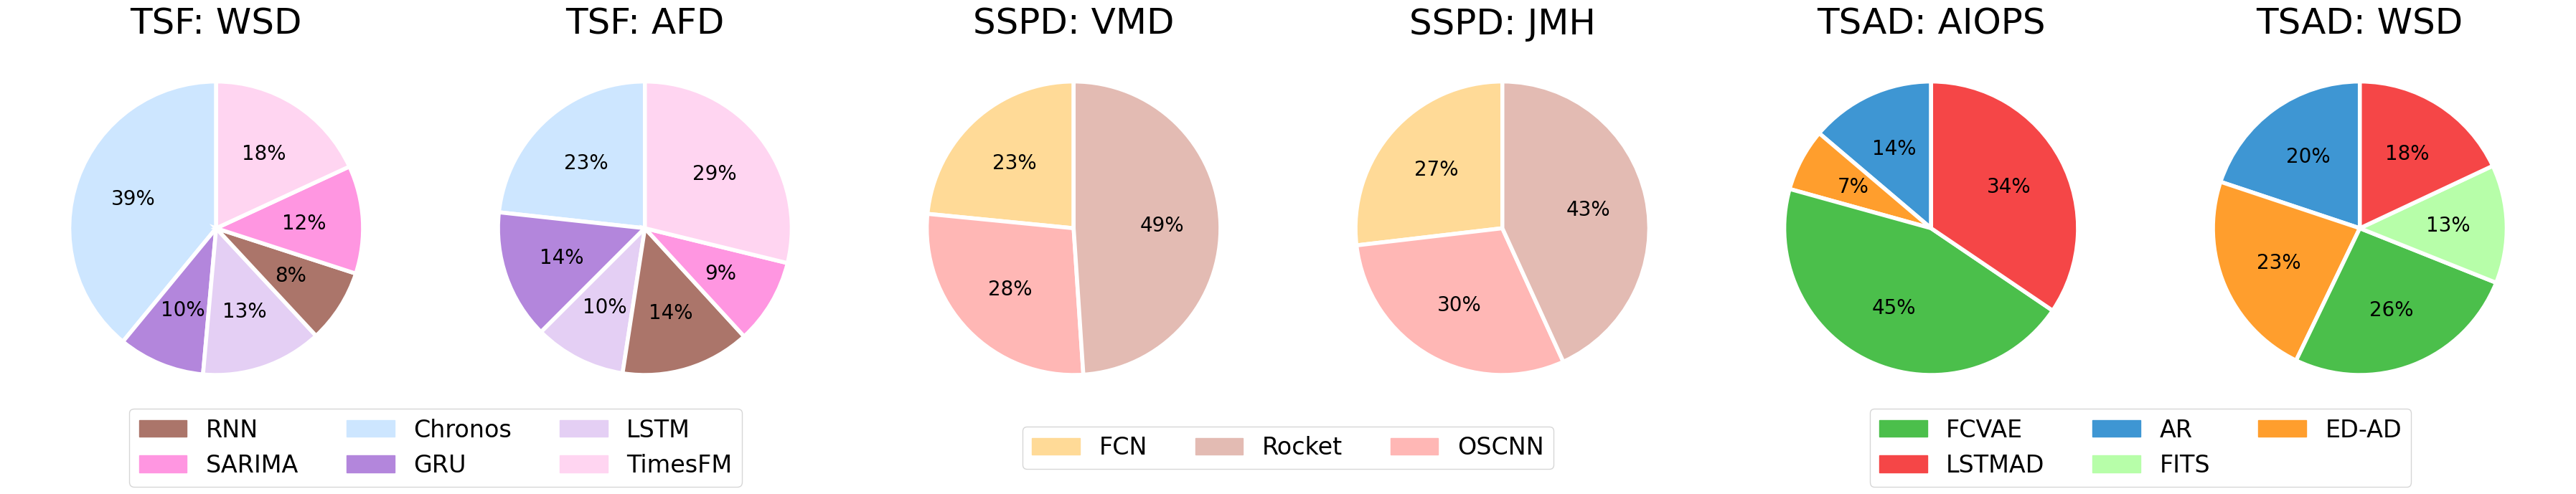

In [8]:
from glob import glob

# Load all experiment files
file_paths = glob("data/metrics/*.csv")  # adjust this to your actual path
all_data = [pd.read_csv(path) for path in file_paths]

# Define a consistent color palette for the pie charts
colors_palette = plt.cm.Paired(range(10))  # Adjust the range if there are more than 10 models
# Step 1: Collect all unique models across experiments
all_models = set()

# Iterate through each file to collect models
for path in file_paths:
    df = pd.read_csv(path, index_col=0)
    all_models.update(df.columns.tolist())

# Step 2: Create a consistent color palette for all models
palette = sns.color_palette("tab20", len(all_models))  # You can use other color palettes too
palette = [(min(r + 0.12, 1), min(g + 0.12, 1), min(b + 0.12, 1)) for r, g, b in palette]
model_to_color = dict(zip(sorted(all_models), palette))

# Container for all results
summary = []

# Determine the number of experiments and create a figure with enough subplots
num_experiments = len(file_paths)
fig, axes = plt.subplots(1, num_experiments, figsize=(6 * num_experiments, 6))

# If there's only one experiment, axes will not be an array, so we need to adjust
if num_experiments == 1:
    axes = [axes]

font_size_title = 36  # Font size for titles
font_size_labels = 24  # Font size for labels
font_size_percent = 20  # Font size for percentage text

model_rename_map = {
    "LSTMADalpha": "LSTMAD",
    "RNN_RNN": "RNN",
    "RNN_LSTM": "LSTM",
    "RNN_GRU": "GRU",
    "EncDecAD": "ED-AD"
    # Add other model mappings as needed
}

metric_df_mapping = {
    "WSD_3k_metrics": "TSF: WSD",
    "Azure_metrics": "TSF: AFD",
    "fbeta.2_VMs": "SSPD: VMD",
    "fbeta.2_jmh": "SSPD: JMH",
    "AIOPS_metrics": "TSAD: AIOPS",
    "WSD_metrics": "TSAD: WSD",
}

# Iterate through each file and generate the pie chart for each experiment
for idx, path in enumerate(file_paths):
    dataset_name = Path(path).stem
    experiment_name = f"Experiment {dataset_name}"
    
    # Load dataframe for each experiment
    df = pd.read_csv(path, index_col=0)
    
    # Count the wins: Where each model has the minimum value per ts_id
    if dataset_name in ("WSD_3k_metrics", "Azure_metrics"):
        print("min for", dataset_name)
        winners = df.idxmin(axis=1)
    else:
        print("max for", dataset_name)
        winners = df.idxmax(axis=1)
    
    win_counts = winners.value_counts().rename("wins")
    win_counts = win_counts[sorted(win_counts.index)]  
    
    colors = [model_to_color[model] for model in win_counts.index]
    
    renamed_labels = [model_rename_map.get(model, model) for model in win_counts.index]
    
    wedges, texts, autotexts = axes[idx].pie(win_counts, autopct='%1.0f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 4})
    
    # Set font sizes
    for text in texts:
        text.set_fontsize(font_size_labels)
    for autotext in autotexts:
        autotext.set_fontsize(font_size_percent)
    
    axes[idx].set_title(metric_df_mapping[dataset_name], fontsize=font_size_title)
    
    axes[idx].axis('equal')


legends = [
    ['Chronos', 'TimesFM', 'RNN_GRU', 'RNN_RNN', 'RNN_LSTM', 'SARIMA'],
    ['Rocket', "FCN", 'OSCNN'],
    ['AR', 'EncDecAD', 'FCVAE', 'FITS', 'LSTMADalpha']
]


tsf_colors = [model_to_color[mdl] for mdl in all_models if mdl in legends[0]]
tsf_models = [model_rename_map.get(mdl, mdl) for mdl in all_models if mdl in legends[0]]
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in tsf_colors]
fig.legend(handles, tsf_models, loc='center', bbox_to_anchor=(0.17, -0.05), ncol=3, fontsize=font_size_labels)


ssd_colors = [model_to_color[mdl] for mdl in all_models if mdl in legends[1]]
ssd_models = [model_rename_map.get(mdl, mdl) for mdl in all_models if mdl in legends[1]]
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in ssd_colors]
fig.legend(handles, ssd_models, loc='center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=font_size_labels)


ad_colors = [model_to_color[mdl] for mdl in all_models if mdl in legends[2]]
ad_models = [model_rename_map.get(mdl, mdl) for mdl in all_models if mdl in legends[2]]
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in ad_colors]
fig.legend(handles, ad_models, loc='center', bbox_to_anchor=(0.83, -0.05), ncol=3, fontsize=font_size_labels)

    
# Adjust layout and show the figure with all subplots
plt.tight_layout()
plt.savefig("results/wins_dist.pdf", bbox_inches='tight')
plt.show()